## Loading

In [21]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import os
from data_cleaning_class import DataCleaner
import math
from pca import PCA_Python


pd.set_option('display.max_rows', None)

script_dir = os.getcwd()
csv_path = os.path.join(script_dir , "kl.csv")
print(csv_path)

decoded_df = pd.read_csv(csv_path , encoding="cp1252")

/home/youssef/mia_ai/Task_2/Task2.3/kl.csv


## Cleaning

In [22]:
decoded_df = decoded_df[["Name","Finishing" , "ShortPassing" , "Dribbling" , "SprintSpeed" , "Strength" , "Stamina" , "Interceptions" , "StandingTackle" ,"Value"]]
print(decoded_df[decoded_df["Name"].str.contains("salah", case=False, na=False)])
def parse_currency(val):
    val = str(val).replace('€', '').strip()
    multiplier = 1
    
    if val.endswith('M'):
        multiplier = 1_000_000
        val = val[:-1]
    elif val.endswith('K'):
        multiplier = 1_000
        val = val[:-1]
    try:
        return float(val) * multiplier
    except ValueError:
        return np.nan


decoded_df["Value"] = decoded_df["Value"].apply(parse_currency)

print(decoded_df[decoded_df["Name"].str.contains("salah", case=False, na=False)])
decoded_df = DataCleaner(decoded_df).clean_df()
print("Here3")
decoded_df[decoded_df["name"].str.contains("salah", case=False, na=False)]
print(decoded_df[decoded_df["name"].str.contains("salah", case=False, na=False)])



        Name  Finishing  ShortPassing  Dribbling  SprintSpeed  Strength  \
26  M. Salah       90.0          82.0       89.0         91.0      70.0   

    Stamina  Interceptions  StandingTackle   Value  
26     84.0           55.0            43.0  €69.5M  
        Name  Finishing  ShortPassing  Dribbling  SprintSpeed  Strength  \
26  M. Salah       90.0          82.0       89.0         91.0      70.0   

    Stamina  Interceptions  StandingTackle       Value  
26     84.0           55.0            43.0  69500000.0  
the  cleaning methods worked
Here3
        name  finishing  shortpassing  dribbling  sprintspeed  strength  \
26  M. Salah       90.0          82.0       89.0         91.0      70.0   

    stamina  interceptions  standingtackle       value  
26     84.0           55.0            43.0  69500000.0  


## Data standardizing -we'll ignore that block to try without normalization 
i except that it'll think that those of higher values - features with higher floor limits will domain because they'll seem "dominate" 

In [23]:
decoded_df_standardized = decoded_df.copy()
names = decoded_df_standardized["name"]
feature_cols = decoded_df_standardized.columns.drop("name")
decoded_df_standardized[feature_cols] = (
    decoded_df_standardized[feature_cols] - decoded_df_standardized[feature_cols].mean()
) / decoded_df_standardized[feature_cols].std()

## Similarity matrices


### Similarity metrics 

In [24]:
class SimilarityMetrics():
    def __init__(self , A , B , axis :int = 1):
            self.A = np.array(A) 
            self.B = np.array(B)
            self.axis = axis

    #dot product is a measurement of how two vectors are aligned,in this metric as dot product increases similiarity does
    #and its cos theta between them anyway using simple LA
    def cosine_similarity(self): 
            dot = np.sum(self.A * self.B, axis=self.axis)
            cos_sim = dot / (
                np.linalg.norm(self.A, axis=self.axis) *
                np.linalg.norm(self.B, axis=self.axis)
            )
            return cos_sim
    

    # the shortest path(l2) between two vectors , can be large even if they're with the same angle but difference altitudes
    def euclidean_distance(self):
            return np.linalg.norm(self.A - self.B, axis=self.axis)

    # measures path length using the sum of absolute differences , less sensitive to large outliers because error isn't squared
    def manhattan_distance(self):
            return np.sum(np.abs(self.B - self.A), axis=self.axis)

    # measures the linear relationship between two variables rather than relying on the distance
    # it's suitable if two vectors share the same shape but of difference magnitudes(think that'll make it behave better than the above two for non-normalized data)
    def pearson_correlation(self):
        std_A = self.A - self.A.mean(axis=self.axis, keepdims=True)
        std_B = self.B - self.B.mean(axis=self.axis, keepdims=True)

        num = np.sum(std_A * std_B, axis=self.axis)
        denom = (
            np.sqrt(np.sum(std_A**2, axis=self.axis)) *
            np.sqrt(np.sum(std_B**2, axis=self.axis))
        )

        return num / denom

    #measures the largest diff along one of the axis,useful in things like path_finding on grids -used similar thing for robocon
    #it also makes diagonal moves have the same cost since it's just another axis of movement
    def chebyshev_distance(self):
        return np.max(np.abs(self.A - self.B), axis=self.axis)

## Top 5

In [25]:
def get_top_similar(df: pd.DataFrame , n =  5, target : str = "M. Salah"):
    # smaller value(distance) = more similar for these; higher value (similarity) = more similar for these two
    ascending_map = {
        "cosine_similarity": False,
        "pearson_correlation": False,
        "euclidean_distance": True,
        "manhattan_distance": True,
        "chebyshev_distance": True,
    }
    feature_cols = df.columns.drop("name")
    mask = df["name"].str.lower() == target.lower()
    target_vec = df.loc[mask, feature_cols].values.flatten()


    # exclude the target himself
    others = df[df["name"] != target].reset_index(drop=True)
    A = others[feature_cols].values
    B = np.tile(target_vec, (A.shape[0], 1))

    similarity = SimilarityMetrics(A, B) 
    results = {}
    for metric_name, ascending in ascending_map.items():
        scores = getattr(similarity, metric_name)()
        temp = others[["name"]].copy()
        temp[metric_name] = scores
        temp = temp.sort_values(metric_name, ascending=ascending).head(n)
        results[metric_name] = temp.reset_index(drop=True)

    return results

def plot_top_similar(top5, target="M. Salah"):
    n_metrics = len(top5)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    base_color = "#4C72B0"
    dark_color = "#2C4A78"

    for i, (metric, table) in enumerate(top5.items()):
        ax = axes[i]

        table = table.reset_index()

        preferred = [c for c in table.columns if c.lower() in ("name", "player")]
        name_col = preferred[0] if preferred else next(
            c for c in table.columns if c.lower() == "index"
        )

        if metric in table.columns:
                    score_col = metric
        else:
                    score_col = next(
                        c for c in table.columns
                        if c != name_col and c.lower() != "index" and pd.api.types.is_numeric_dtype(table[c])
                    )

        # similarity: higher = better -> ascending sort puts the best last -> plotted at TOP
        # distance:  lower  = better -> descending sort puts the best last -> plotted at TOP
        ascending = "distance" not in metric.lower()
        table = table.sort_values(score_col, ascending=ascending)
        table = table.iloc[::-1] if False else table  # (kept for clarity, no-op)

        # for barh, first row plots at the bottom -- we want the best match at the TOP
        table = table.sort_values(score_col, ascending=ascending)

        values = table[score_col].to_numpy(dtype=float)
        lo, hi = values.min(), values.max()
        span = hi - lo
        pad = span * 0.15 if span > 0 else abs(hi) * 0.05 or 1.0
        baseline = lo - pad  # suitable lower limit instead of 0, so differences are visible

        y_pos = range(len(table))
        colors = [dark_color if j == len(table) - 1 else base_color for j in range(len(table))]

        bars = ax.barh(y_pos, values - baseline, left=baseline, color=colors, height=0.6)
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(table[name_col].astype(str))
        ax.set_xlim(baseline, hi + pad)

        for bar, val in zip(bars, values):
            ax.annotate(f"{val:.3f}", (bar.get_x() + bar.get_width(), bar.get_y() + bar.get_height() / 2),
                        va="center", ha="left", fontsize=8, xytext=(4, 0),
                        textcoords="offset points", color="#1B3A57")

        ax.set_title(f"Top 10 by {metric}", fontsize=12, weight="bold")
        sns.despine(ax=ax, left=True, bottom=True)
        ax.grid(axis="x", alpha=0.3)

    for j in range(n_metrics, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Most Similar Players to {target}", fontsize=15, weight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Standardized Data

### M.salah


Top 10 by cosine_similarity:
                name  cosine_similarity
0          K. Mbappé           0.996828
1      Marco Asensio           0.995272
2       A. Griezmann           0.994634
3          E. Hazard           0.993910
4            L. Sané           0.993450
5  Cristiano Ronaldo           0.993388
6            G. Bale           0.993146
7      P. Aubameyang           0.992953
8          E. Cavani           0.992612
9        C. Immobile           0.992461

Top 10 by pearson_correlation:
                name  pearson_correlation
0          E. Hazard             0.998190
1          K. Mbappé             0.998144
2          Neymar Jr             0.998010
3          P. Dybala             0.997532
4           L. Messi             0.997117
5       A. Griezmann             0.996548
6      Marco Asensio             0.994098
7            G. Bale             0.994040
8         I. Periši?             0.993377
9  Cristiano Ronaldo             0.992430

Top 10 by euclidean_distance:
     

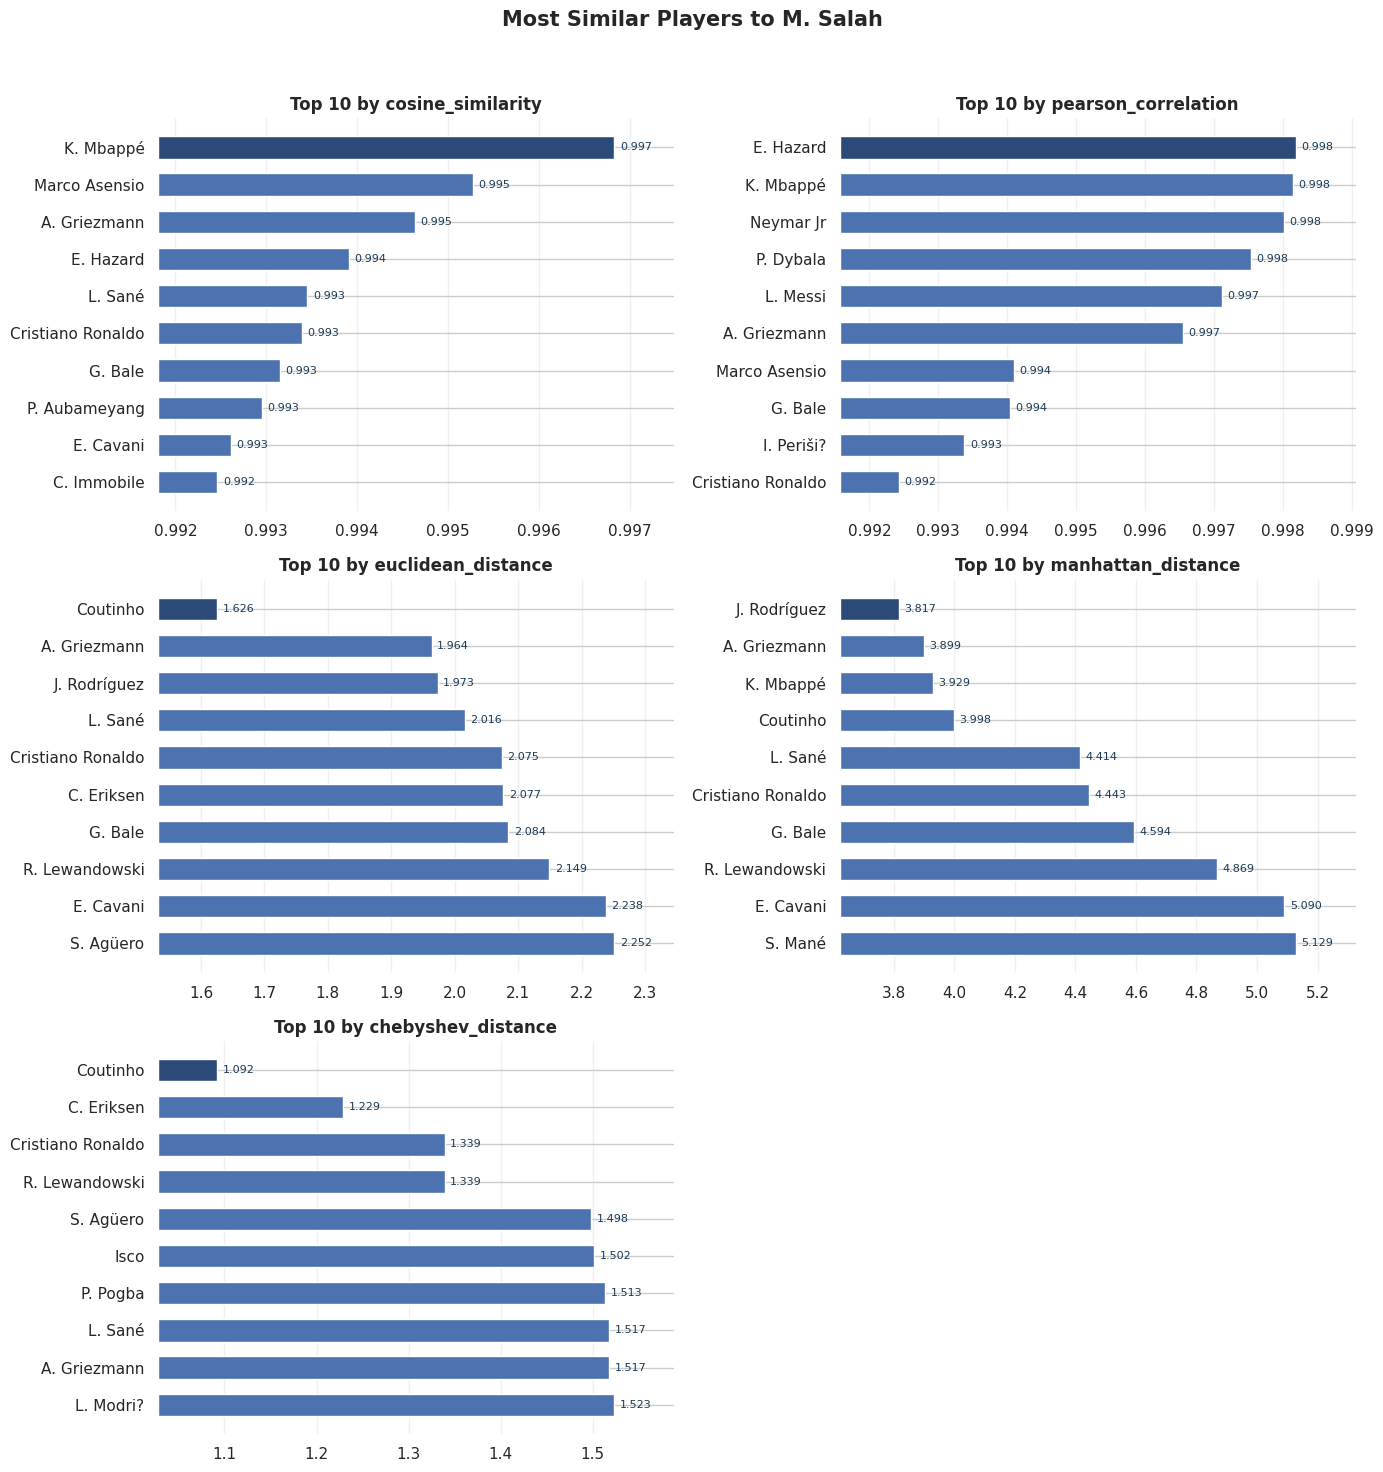

In [26]:
top10_salah = get_top_similar(df = decoded_df_standardized, n=10, target="M. Salah")
for metric, table in top10_salah.items():
    print(f"\nTop {10} by {metric}:") 
    print(table)

plot_top_similar(top10_salah, target="M. Salah")

### trying a goalkeeper 




Top 10 by cosine_similarity:
            name  cosine_similarity
0        Ederson           0.987961
1  M. ter Stegen           0.982654
2       J. Oblak           0.974840
3    T. Courtois           0.971649
4        Alisson           0.970812
5         De Gea           0.961217
6  G. Donnarumma           0.948808
7  S. Handanovi?           0.947047
8        B. Leno           0.946636
9       K. Navas           0.941011

Top 10 by pearson_correlation:
            name  pearson_correlation
0        B. Leno             0.991703
1        Ederson             0.988213
2  S. Handanovi?             0.985315
3           Neto             0.983937
4        T. Horn             0.983913
5        Alisson             0.983116
6  M. ter Stegen             0.982655
7  G. Donnarumma             0.982391
8  Sergio Asenjo             0.982180
9   J. Cillessen             0.980802

Top 10 by euclidean_distance:
            name  euclidean_distance
0        Ederson            1.271756
1        Alisson   

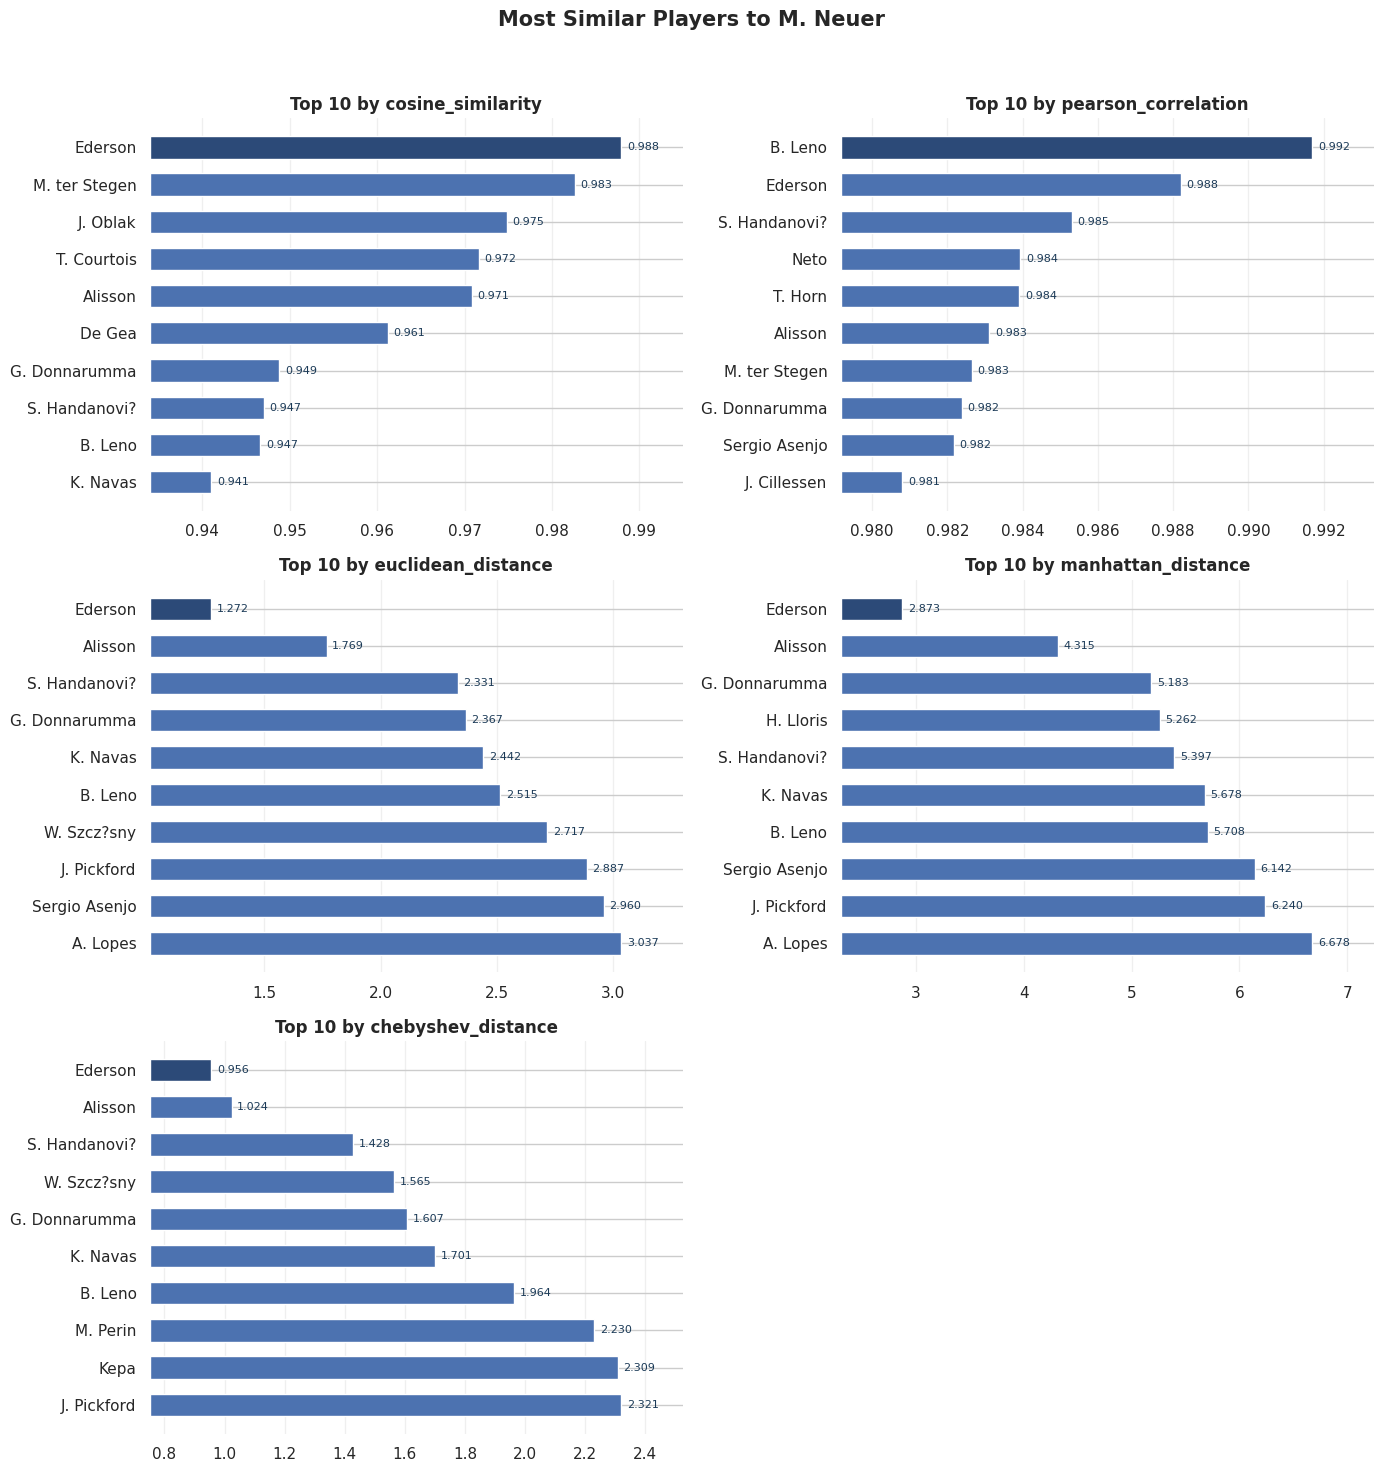

In [27]:
top10_neuer = get_top_similar(df = decoded_df_standardized, n=10, target="M. Neuer")
for metric, table in top10_neuer.items():
    print(f"\nTop {10} by {metric}:")
    print(table)

plot_top_similar(top10_neuer, target="M. Neuer")

## Not Standardized

In [28]:
top10_non_standard = get_top_similar(df = decoded_df, n=10, target="M. Salah")
for metric, table in top10_non_standard.items():
    print(f"\nTop {10} by {metric}:")
    print(table)


Top 10 by cosine_similarity:
                name  cosine_similarity
0           Coutinho                1.0
1       J. Rodríguez                1.0
2            L. Sané                1.0
3     Bernardo Silva                1.0
4         C. Eriksen                1.0
5          E. Cavani                1.0
6      P. Aubameyang                1.0
7     R. Lewandowski                1.0
8  Cristiano Ronaldo                1.0
9       A. Griezmann                1.0

Top 10 by pearson_correlation:
               name  pearson_correlation
0         E. Hazard                  1.0
1         Neymar Jr                  1.0
2         K. Mbappé                  1.0
3         P. Dybala                  1.0
4          L. Messi                  1.0
5           G. Bale                  1.0
6      A. Griezmann                  1.0
7     Marco Asensio                  1.0
8  Anderson Talisca                  1.0
9    R. Lewandowski                  1.0

Top 10 by euclidean_distance:
           name 

## Using PCA

In [29]:
def get_shortlist_names(results: dict, unique: bool = True) :
    if not unique:
        return {metric: table["name"].tolist() for metric, table in results.items()}

    all_names = []
    for table in results.values():
        all_names.extend(table["name"].tolist())

    # preserve order, drop duplicates
    seen = set()
    ordered_unique = []
    for name in all_names:
        if name not in seen:
            seen.add(name)
            ordered_unique.append(name)

    return ordered_unique

def PCA_similarity(df : pd.DataFrame , target = "M. Salah" , n:int =2):
    feature_cols = df.columns.drop("name")
    df = df.dropna(subset=feature_cols)  #removing all nulls (goal keepers) since that broken eigen value -not converging

    X = df[feature_cols].values.tolist()

    pca = PCA_Python(X , n)
    projected , explained_variance = pca.get_PCA()
    print (f"PCA explained {explained_variance*100}% of the variance")

    pc_cols = [f"PC{i+1}" for i in range(n)]
    pca_df = pd.DataFrame(projected, columns=pc_cols)
    pca_df["name"] = df["name"].values #PCAn then names

    top10 =get_top_similar(df=decoded_df_standardized, n=5, target="M. Salah")
    shortlist_names = get_shortlist_names(top10)


    # visual 
    if n == 2 :
        ig, ax = plt.subplots(figsize=(10, 8))

        # all players in grey
        ax.scatter(pca_df["PC1"], pca_df["PC2"], c="lightgrey", s=15, alpha=0.5, label="All players")

        # shortlist highlighted
        shortlist_pts = pca_df[pca_df["name"].isin(shortlist_names)]
        ax.scatter(shortlist_pts["PC1"], shortlist_pts["PC2"], c="seagreen", s=80,
                edgecolors="black", label="Shortlist", zorder=3)

        # target highlighted separately, bigger/different color
        target_pt = pca_df[pca_df["name"] == target]
        ax.scatter(target_pt["PC1"], target_pt["PC2"], c="crimson", s=200, marker="*",
                edgecolors="black", label=target, zorder=4)

        # label the shortlist + target points
        for _, row in pd.concat([shortlist_pts, target_pt]).iterrows():
            ax.annotate(row["name"], (row["PC1"], row["PC2"]),
                        textcoords="offset points", xytext=(6, 6), fontsize=9)

        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_title(f"Player Pool in PCA Space — {target} and Shortlist Highlighted")
        ax.legend()
        plt.tight_layout()
        plt.show()

    elif n == 3:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(projection="3d")

        # all players in grey
        ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"],
                   c="lightgrey", s=15, alpha=0.4, label="All players")

        # shortlist highlighted
        shortlist_pts = pca_df[pca_df["name"].isin(shortlist_names)]
        ax.scatter(shortlist_pts["PC1"], shortlist_pts["PC2"], shortlist_pts["PC3"],
                   c="seagreen", s=80, edgecolors="black", label="Shortlist")

        # target highlighted separately
        target_pt = pca_df[pca_df["name"] == target]
        ax.scatter(target_pt["PC1"], target_pt["PC2"], target_pt["PC3"],
                   c="crimson", s=200, marker="*", edgecolors="black", label=target)

        # label the shortlist + target points
        for _, row in pd.concat([shortlist_pts, target_pt]).iterrows():
            ax.text(row["PC1"], row["PC2"], row["PC3"], row["name"], fontsize=8)

        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        ax.set_title(f"Player Pool in PCA Space (3D) — {target} and Shortlist Highlighted")
        ax.legend()
        plt.tight_layout()
        plt.show()

PCA explained 70.20260312490085% of the variance


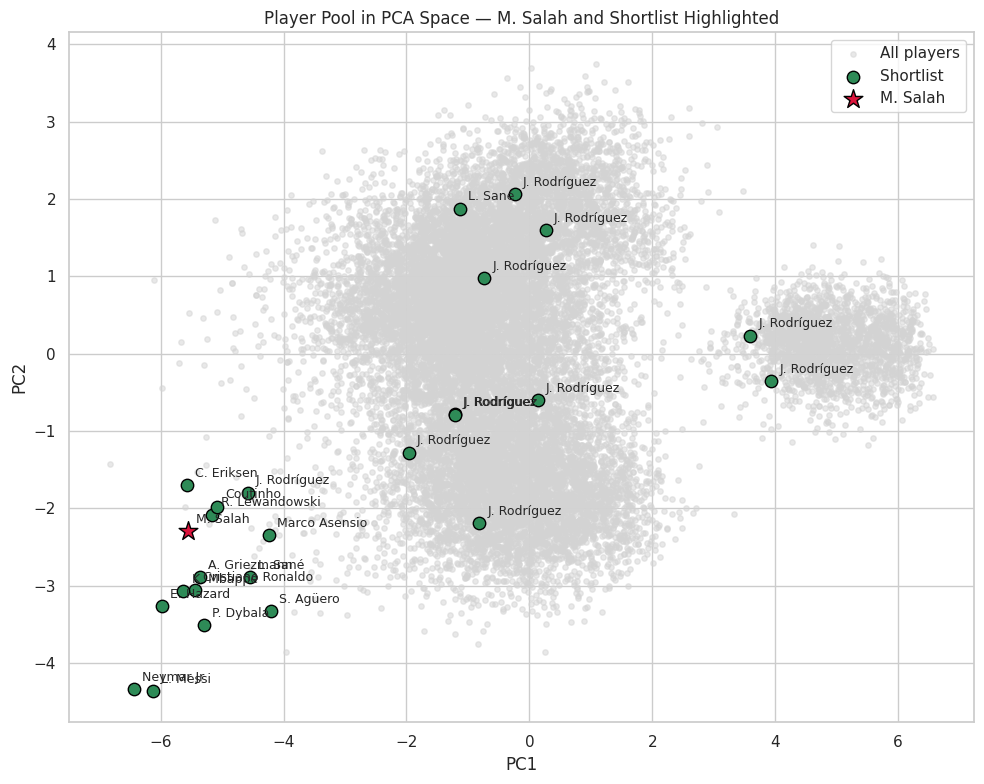

PCA explained 81.0292068025256% of the variance


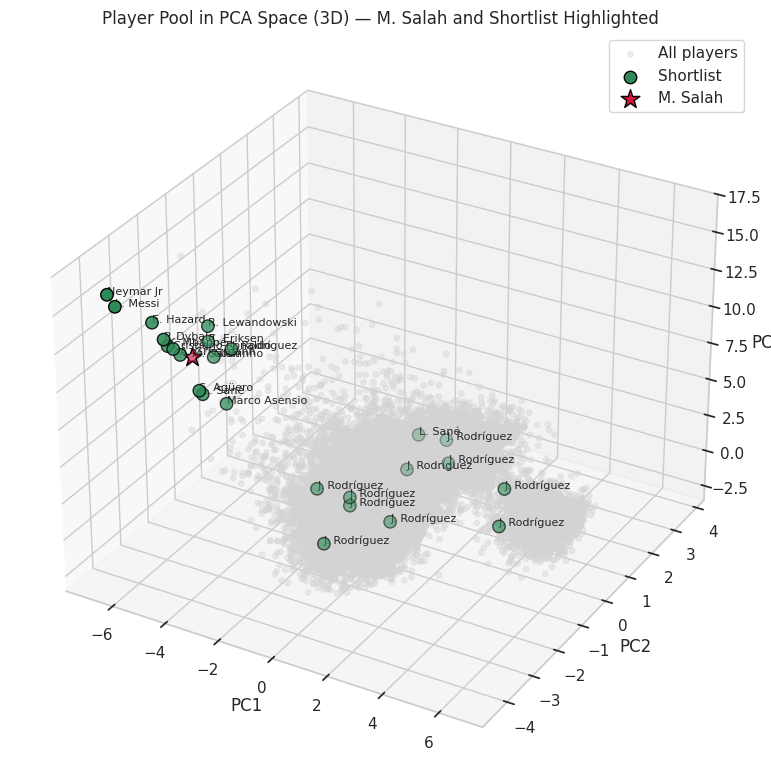

PCA explained 81.0292068025256% of the variance


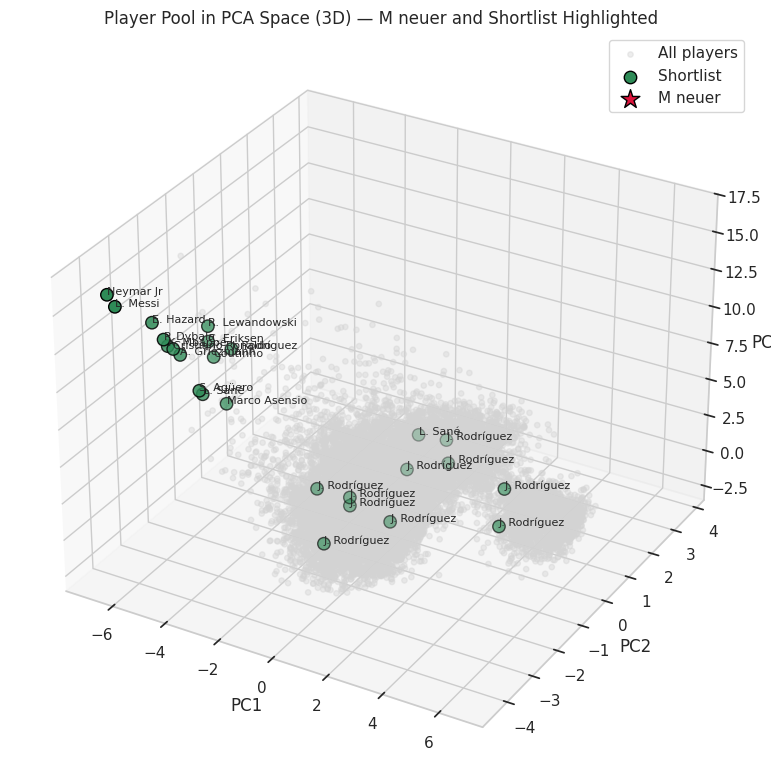

In [ ]:
PCA_similarity(df=decoded_df, n = 2) #70% variance is explained
PCA_similarity(df=decoded_df, n = 3)


#this j rodriguez is very off